# 📊 Evaluation Only — Load Model & Chạy Lại Classification Report
Chỉ load model đã train, tạo lại test set với cùng seed, rồi predict & đánh giá.
**Không cần train lại.**

In [8]:
import os, re, cv2, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Layer
from concurrent.futures import ThreadPoolExecutor
import tensorflow.keras.backend as K

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# ── Reproducibility (phải giống lúc train) ──────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Hyperparams (giữ nguyên như lúc train) ──────────────────────────
IMG_SIZE    = 128
FRAME_COUNT = 15
BATCH_SIZE  = 32
CLASSES     = ['Normal', 'Violence']

print("✅ Setup xong")

✅ Setup xong


## 1. Khai báo lại Custom Layers (cần thiết để load model)

In [9]:
@tf.keras.utils.register_keras_serializable()
class TemporalAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', shape=(input_shape[-1], 1),
                                  initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='att_bias', shape=(1,),
                                  initializer='zeros', trainable=True)
        super().build(input_shape)
    def call(self, x):
        e = K.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        alpha = K.softmax(K.squeeze(e, axis=-1))
        return K.sum(x * K.expand_dims(alpha, axis=-1), axis=1), alpha
    def get_config(self):
        return super().get_config()

@tf.keras.utils.register_keras_serializable()
class ReshapeToFrames(Layer):
    def __init__(self, img_size, **kwargs):
        super().__init__(**kwargs); self.img_size = img_size
    def call(self, x):
        return tf.reshape(x, [-1, self.img_size, self.img_size, 3])
    def get_config(self):
        cfg = super().get_config(); cfg.update({"img_size": self.img_size}); return cfg

@tf.keras.utils.register_keras_serializable()
class ReshapeToSequence(Layer):
    def __init__(self, frame_count, feat_dim, **kwargs):
        super().__init__(**kwargs)
        self.frame_count = frame_count; self.feat_dim = feat_dim
    def call(self, x):
        return tf.reshape(x, [-1, self.frame_count, self.feat_dim])
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"frame_count": self.frame_count, "feat_dim": self.feat_dim}); return cfg

print("✅ Custom layers đã đăng ký")

✅ Custom layers đã đăng ký


## 2. Load model đã train

In [10]:
import keras
keras.config.enable_unsafe_deserialization()

MODEL_PATH = '/kaggle/input/datasets/visin21/cctv90/CCTV_Violence_Finetuned.keras'

# ── Build lại architecture (giống hệt lúc train) ──────────────────
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

K.clear_session()
base_model = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False
FEAT_DIM = base_model.output_shape[-1]  # 1280

video_input = Input(shape=(FRAME_COUNT, IMG_SIZE, IMG_SIZE, 3))

# Dùng Lambda đúng như lúc train (có output_shape để tránh lỗi infer)
x = Lambda(
    lambda z: tf.reshape(z, [-1, IMG_SIZE, IMG_SIZE, 3]),
    output_shape=(IMG_SIZE, IMG_SIZE, 3)
)(video_input)
x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Lambda(
    lambda z: tf.reshape(z, [-1, FRAME_COUNT, FEAT_DIM]),
    output_shape=(FRAME_COUNT, FEAT_DIM)
)(x)

x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3))(x)
context_vector, attention_weights = TemporalAttention(name='attention_layer')(x)

x = Dense(64, activation='relu')(context_vector)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax', dtype='float32')(x)

model = Model(inputs=video_input, outputs=output)

# ── Chỉ load weights, bỏ qua architecture trong file ──────────────
model.load_weights(MODEL_PATH)
print("✅ Load weights thành công!")
model.summary()

✅ Load weights thành công!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 15, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 15, 128)        │       688,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ [(None, 128), (None,   │           129 │
│ (TemporalAttention)             │ 15)]                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,955,139 (11.27 MB)

 Trainable params: 697,155 (2.66 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3. Tạo lại Test Set (cùng seed 42 → cùng kết quả split)

In [11]:
SOURCES = [
    Path('/kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted_sec_split'),
    Path('/kaggle/input/rwf2000/RWF-2000'),
    Path('/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset')
]

def canonical_scene_key(path):
    stem = path.stem.lower()
    stem = re.sub(r'(_clip\d+|_part\d+|_seg\d+|-clip\d+|-part\d+)$', '', stem)
    return f"{path.parent.name.lower()}::{stem}"

def load_data():
    records = []
    for base in SOURCES:
        if not base.exists(): continue
        for path in base.rglob('*'):
            if path.suffix.lower() not in ['.mp4', '.avi']: continue
            folder = path.parent.name.lower()
            if folder in ['normal', 'nonfight', 'nonviolence']: label = 0
            elif folder in ['violence', 'weaponized', 'fight']: label = 1
            else: continue
            group_id = f"{base.name}::{canonical_scene_key(path)}"
            records.append((str(path), label, group_id))
    return records

records = load_data()
paths  = np.array([r[0] for r in records])
labels = np.array([r[1] for r in records])
groups = np.array([r[2] for r in records])

# Dùng ĐÚNG seed=42 để ra cùng test split
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
_, test_idx = next(gss_test.split(paths, labels, groups))
X_test_p = paths[test_idx]
y_test   = labels[test_idx]

print(f"📊 Test set: {len(X_test_p)} videos")
unique, counts = np.unique(y_test, return_counts=True)
print(f"   Normal={counts[0]} | Violence={counts[1]}")

📊 Test set: 716 videos
   Normal=322 | Violence=394


## 4. Tạo Test Generator (shuffle=False — đây là fix chính)

In [12]:
def extract(path):
    f = []
    try:
        cap = cv2.VideoCapture(path)
        if not cap.isOpened(): raise IOError(f"Không mở được: {path}")
        t = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        s = max(t // FRAME_COUNT, 1)
        for i in range(FRAME_COUNT):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * s)
            ret, frame = cap.read()
            if not ret: break
            frame = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
            f.append(preprocess_input(frame.astype(np.float32)))
        cap.release()
    except Exception as e:
        print(f"⚠️ Lỗi video: {e}")
    while len(f) < FRAME_COUNT:
        f.append(np.zeros((IMG_SIZE, IMG_SIZE, 3), np.float32) - 1.0)
    return np.array(f[:FRAME_COUNT], np.float32)


class TestGenerator(tf.keras.utils.Sequence):
    """Generator chỉ dùng cho test — KHÔNG shuffle, KHÔNG augment."""
    def __init__(self, paths, labels):
        self.p  = list(paths)
        self.l  = list(labels)
        self.ex = ThreadPoolExecutor(max_workers=8)

    def __len__(self):
        return int(np.ceil(len(self.p) / BATCH_SIZE))

    def __getitem__(self, i):
        bx = self.p[i * BATCH_SIZE:(i + 1) * BATCH_SIZE]
        by = self.l[i * BATCH_SIZE:(i + 1) * BATCH_SIZE]
        videos = np.array(list(self.ex.map(extract, bx)), dtype=np.float32)
        return videos, tf.keras.utils.to_categorical(by, 2)

    def on_epoch_end(self):
        pass  # ✅ Không shuffle

    def __del__(self):
        self.ex.shutdown(wait=False)

test_gen = TestGenerator(X_test_p, y_test)
print(f"✅ TestGenerator sẵn sàng: {len(test_gen)} batches")

✅ TestGenerator sẵn sàng: 23 batches


## 5. Predict & Classification Report (đã fix thứ tự)

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 177s 7s/step

BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):
              precision    recall  f1-score   support

      Normal     0.9352    0.8509    0.8911       322
    Violence     0.8865    0.9518    0.9180       394

    accuracy                         0.9064       716
   macro avg     0.9108    0.9014    0.9045       716
weighted avg     0.9084    0.9064    0.9059       716



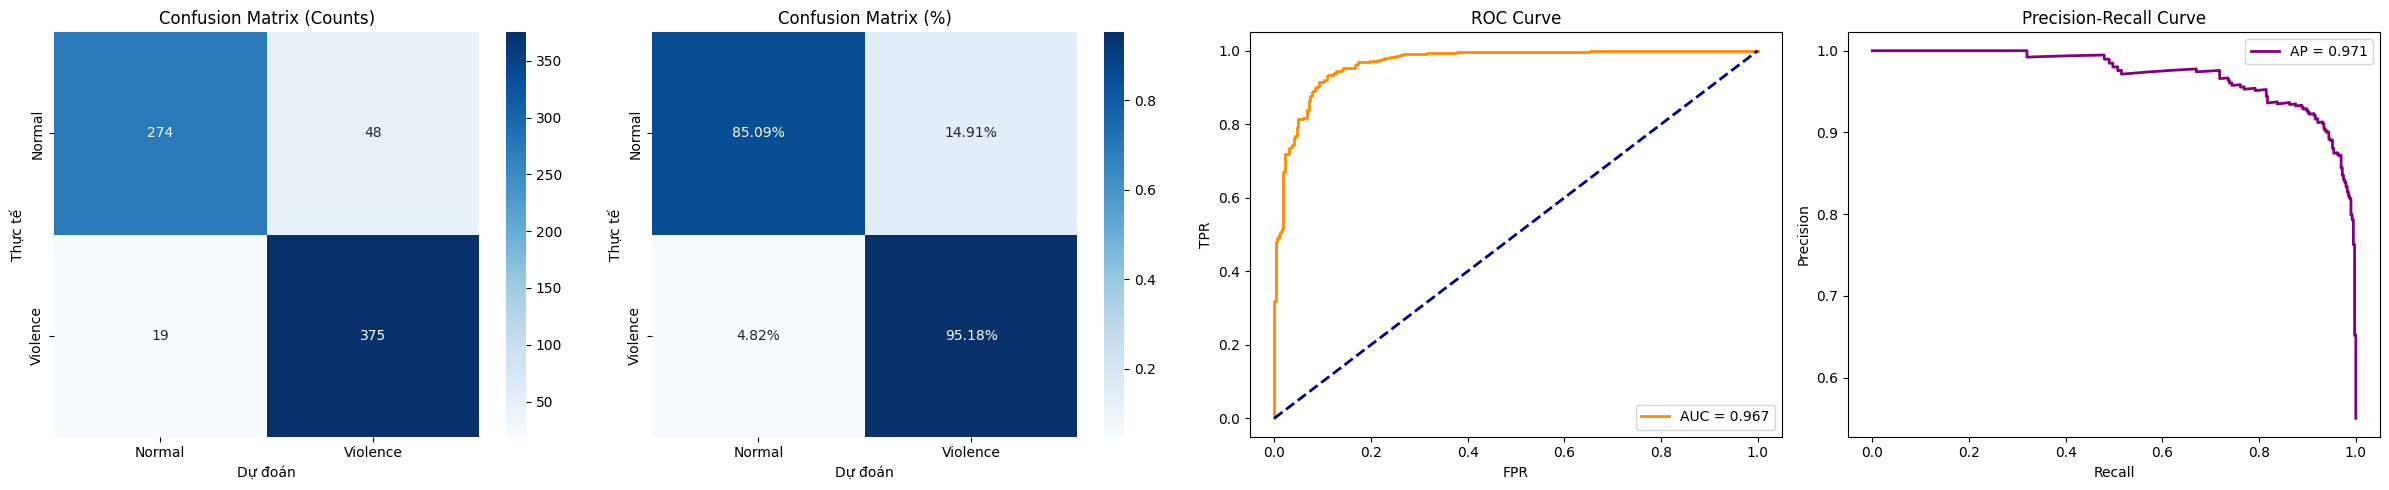

✅ Xong!


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from datetime import datetime

# ✅ FIX: y_true lấy thẳng từ split — KHÔNG qua generator (tránh bị shuffle)
y_true_all   = y_test.copy()

# Predict
y_pred_prob  = model.predict(test_gen, verbose=1)
y_pred_class = np.argmax(y_pred_prob, axis=1)

# ── Classification Report ────────────────────────────────────────────
report_str = classification_report(y_true_all, y_pred_class, target_names=CLASSES, digits=4)
print("\nBÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):")
print(report_str)

# ── Vẽ biểu đồ ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

cm = confusion_matrix(y_true_all, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Confusion Matrix (%)')
axes[1].set_ylabel('Thực tế'); axes[1].set_xlabel('Dự đoán')

fpr, tpr, _ = roc_curve(y_true_all, y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_title('ROC Curve'); axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR'); axes[2].legend()

precision, recall, _ = precision_recall_curve(y_true_all, y_pred_prob[:, 1])
ap = average_precision_score(y_true_all, y_pred_prob[:, 1])
axes[3].plot(recall, precision, color='purple', lw=2, label=f'AP = {ap:.3f}')
axes[3].set_title('Precision-Recall Curve')
axes[3].set_xlabel('Recall'); axes[3].set_ylabel('Precision'); axes[3].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/evaluation_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Xong!")